In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import zarr
import tqdm

In [2]:
# --- Stelle sicher, dass dies die Version der Klasse ist, die du ausführst ---

class MRI_Motion_Dataset(Dataset):
    """
    Lädt gepaarte 3D-MRT-Volumen (moving, fixed) dynamisch aus ZWEI separaten
    4D-Zarr-Dateien, um den Arbeitsspeicher nicht zu überlasten.
    """
    # Ersetze __init__ und __getitem__ in deiner MRI_Motion_Dataset-Klasse.
    
    def __init__(self, moving_zarr_path, fixed_zarr_path):
        super().__init__()
        self.moving_zarr_array = zarr.open(moving_zarr_path, mode='r')
        self.fixed_zarr_array = zarr.open(fixed_zarr_path, mode='r')
    
        # ... (Die Dimensions- und Längen-Checks bleiben wie zuvor) ...
        if self.fixed_zarr_array.ndim != 4: # etc.
            raise ValueError(...)
        if self.moving_zarr_array.ndim != 4: # etc.
             raise ValueError(...)
        if self.moving_zarr_array.shape[3] != self.fixed_zarr_array.shape[3]:
            raise ValueError(...)
    
        self.num_images = self.moving_zarr_array.shape[3]
    
        # Berechne die neue, gepaddete Form
        original_shape = self.fixed_zarr_array.shape # (H, W, D, T)
        
        # HIER IST DIE LOGIK FÜR DAS PADDING
        # Wir wollen, dass D, H, W durch 4 teilbar sind (wegen 2 Pooling-Layern)
        self.padded_shape = [s for s in original_shape[:3]] # Kopiere H, W, D
        for i in range(3):
            if self.padded_shape[i] % 4 != 0:
                self.padded_shape[i] = (self.padded_shape[i] // 4 + 1) * 4
    
        # Speichere die für PyTorch nötige (D, H, W) Form
        # (wir nehmen die neuen, gepaddeten Größen)
        self.input_shape = (self.padded_shape[2], self.padded_shape[1], self.padded_shape[0])
        
        print(f"Original H,W,D: {original_shape[:3]}. Padded H,W,D: {self.padded_shape}")
    
    
    def __getitem__(self, idx):
        # Lade die Numpy-Arrays aus den Zarr-Dateien
        moving_volume_np = self.moving_zarr_array[..., idx]
        fixed_volume_np = self.fixed_zarr_array[..., idx]

        # Konvertiere zu Tensoren und passe die Dimensionen an -> (C, D, H, W)
        moving_volume = torch.from_numpy(moving_volume_np.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
        fixed_volume = torch.from_numpy(fixed_volume_np.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)

        # --- KORRIGIERTE PADDING-BERECHNUNG ---
        # self.padded_shape ist (H, W, D) -> [shape[0], shape[1], shape[2]]
        # moving_volume.shape ist (C, D, H, W) -> [shape[0], shape[1], shape[2], shape[3]]

        # Korrekte Zuordnung der Dimensionen:
        pad_d = self.padded_shape[2] - moving_volume.shape[1]  # Tiefe: D
        pad_h = self.padded_shape[0] - moving_volume.shape[2]  # Höhe: H
        pad_w = self.padded_shape[1] - moving_volume.shape[3]  # Breite: W

        # F.pad erwartet die Padding-Werte in umgekehrter Reihenfolge der Dimensionen (W, H, D)
        padding = (pad_w // 2, pad_w - pad_w // 2,
                   pad_h // 2, pad_h - pad_h // 2,
                   pad_d // 2, pad_d - pad_d // 2)

        # Wende das Padding auf beide Volumen an
        moving_volume = F.pad(moving_volume, padding, "constant", 0)
        fixed_volume = F.pad(fixed_volume, padding, "constant", 0)

        return moving_volume, fixed_volume
    
    def __len__(self):
        return self.num_images

In [3]:
class SpatialTransformer3D(nn.Module):
    """
    Wendet ein Verschiebungsfeld (displacement field) auf ein 3D-Volumen an.
    """
    def __init__(self, size):
        super().__init__()
        # Erzeuge ein Gitter mit Koordinaten von -1 bis 1
        vectors = [torch.arange(0, s) for s in size]
        grids = torch.meshgrid(vectors, indexing='ij')
        grid = torch.stack(grids)
        grid = grid.unsqueeze(0)
        self.register_buffer('grid', grid.float(), persistent=False)

    def forward(self, src, flow):
        # src: (B, 1, D, H, W) - das zu transformierende Bild
        # flow: (B, 3, D, H, W) - das Verschiebungsfeld
        
        new_locs = self.grid + flow
        shape = flow.shape[2:]

        # Normalisiere die Koordinaten auf den Bereich [-1, 1] für grid_sample
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2 * (new_locs[:, i, ...] / (shape[i] - 1) - 0.5)

        # Permutiere die Dimensionen, um sie an grid_sample anzupassen
        new_locs = new_locs.permute(0, 2, 3, 4, 1)
        new_locs = new_locs[..., [2, 1, 0]] # Invertiere die Koordinatenreihenfolge

        return F.grid_sample(src, new_locs, align_corners=True, padding_mode="border")

In [4]:
class UNet3D(nn.Module):
    """
    Ein einfaches 3D U-Net, das als Registrierungsnetz dient.
    Es nimmt zwei Bilder und gibt ein Verschiebungsfeld aus.
    """
    def __init__(self, in_channels=2, out_channels=3):
        super().__init__()
        # Vereinfachtes U-Net - für ein echtes Projekt wäre dies komplexer
        self.enc1 = self._conv_block(in_channels, 16)
        self.enc2 = self._conv_block(16, 32)
        self.pool = nn.MaxPool3d(2)
        
        self.bottleneck = self._conv_block(32, 64)
        
        self.upconv2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(64, 32)
        
        self.upconv1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(32, 16)
        
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)
        # Initialisiere die letzte Schicht mit Nullen, damit die Transformation am Anfang Null ist
        self.final_conv.weight.data.zero_()
        self.final_conv.bias.data.zero_()

    def _conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv3d(in_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x_fixed, x_moving):
        x = torch.cat([x_fixed, x_moving], dim=1)
        
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        
        # Bottleneck
        b = self.bottleneck(self.pool(e2))
        
        # Decoder
        d2 = self.upconv2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return self.final_conv(d1)

In [5]:
class RegistrationModel(nn.Module):
    """
    Das komplette Registrierungsmodell, das das U-Net und den Spatial Transformer kombiniert.
    """
    def __init__(self, input_size):
        super().__init__()
        self.registration_net = UNet3D()
        self.spatial_transformer = SpatialTransformer3D(size=input_size)

    def forward(self, moving, fixed):
        displacement_field = self.registration_net(fixed, moving)
        warped_moving = self.spatial_transformer(moving, displacement_field)
        return warped_moving, displacement_field

In [6]:
def ncc_loss(img1, img2):
    """ Berechnet den Normalized Cross-Correlation Loss """
    img1_mean = img1.mean(dim=[2,3,4], keepdim=True)
    img2_mean = img2.mean(dim=[2,3,4], keepdim=True)
    
    img1_std = img1.std(dim=[2,3,4], keepdim=True)
    img2_std = img2.std(dim=[2,3,4], keepdim=True)
    
    numerator = ((img1 - img1_mean) * (img2 - img2_mean)).mean(dim=[2,3,4], keepdim=True)
    denominator = img1_std * img2_std + 1e-6
    
    ncc = (numerator / denominator).mean()
    return 1 - ncc # Wir wollen die Ähnlichkeit maximieren, also den Verlust minimieren

def smooth_loss(displacement_field):
    """ Berechnet den Glättungsverlust, um physikalisch plausible Transformationen zu fördern """
    dy = torch.abs(displacement_field[:, :, 1:, :, :] - displacement_field[:, :, :-1, :, :])
    dx = torch.abs(displacement_field[:, :, :, 1:, :] - displacement_field[:, :, :, :-1, :])
    dz = torch.abs(displacement_field[:, :, :, :, 1:] - displacement_field[:, :, :, :, :-1])
    return (torch.mean(dx**2) + torch.mean(dy**2) + torch.mean(dz**2)) / 3.0

In [8]:
# Ersetze die alte ncc_loss-Funktion mit dieser Klasse
class LocalNCCLoss(nn.Module):
    """
    Berechnet den lokalen Normalized Cross-Correlation Loss.
    """
    def __init__(self, window_size=9):
        super().__init__()
        self.window_size = window_size
        self.padding = window_size // 2

        # Erstelle einen konstanten Faltungs-Kernel für die Mittelwertberechnung
        self.avg_pool = nn.AvgPool3d(kernel_size=self.window_size, stride=1, padding=self.padding)

    def forward(self, img1, img2):
        # Berechne die lokalen Mittelwerte
        mu1 = self.avg_pool(img1)
        mu2 = self.avg_pool(img2)

        # Berechne die lokalen Varianzen
        mu1_sq = mu1 * mu1
        mu2_sq = mu2 * mu2

        sigma1_sq = self.avg_pool(img1 * img1) - mu1_sq
        sigma2_sq = self.avg_pool(img2 * img2) - mu2_sq

        # Berechne die lokale Kovarianz
        covar = self.avg_pool(img1 * img2) - mu1 * mu2

        # Berechne den NCC-Wert
        numerator = covar * covar
        denominator = sigma1_sq * sigma2_sq

        # Vermeide Division durch Null
        ncc = torch.mean(numerator / (denominator + 1e-6))

        # Da wir die Ähnlichkeit maximieren wollen, geben wir 1 - ncc zurück
        return 1 - ncc

# Im Trainingsskript initialisierst du dann:
# similarity_loss_fn = LocalNCCLoss().to(device)
# und rufst auf:
# similarity_loss = similarity_loss_fn(warped_image, fixed_batch)
    def smooth_loss(displacement_field):
        """ Berechnet den Glättungsverlust, um physikalisch plausible Transformationen zu fördern """
        dy = torch.abs(displacement_field[:, :, 1:, :, :] - displacement_field[:, :, :-1, :, :])
        dx = torch.abs(displacement_field[:, :, :, 1:, :] - displacement_field[:, :, :, :-1, :])
        dz = torch.abs(displacement_field[:, :, :, :, 1:] - displacement_field[:, :, :, :, :-1])
        return (torch.mean(dx**2) + torch.mean(dy**2) + torch.mean(dz**2)) / 3.0

In [9]:
if __name__ == '__main__':
    # --- Konfiguration ---
    MOVING_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE" 
    FIXED_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
    
    MODEL_SAVE_PATH = "./registration_model.pth"
    
    BATCH_SIZE = 1 
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 50 
    SMOOTH_REG_WEIGHT = 0.1 # Gewicht für den Glättungs-Loss

    # --- Setup ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Verwende Gerät: {device}")

    # Überprüfe, ob die Zarr-Dateien existieren
    if not os.path.exists(MOVING_ZARR_PATH) or not os.path.exists(FIXED_ZARR_PATH):
        print(f"Fehler: Eine oder beide Zarr-Dateien nicht gefunden.")
        print(f"Moving Path: {MOVING_ZARR_PATH}")
        print(f"Fixed Path: {FIXED_ZARR_PATH}")
        print("Bitte passe die Pfade im Skript an.")
    else:
        # --- Daten laden ---
        # HIER ERFOLGT DIE ANPASSUNG: Übergib beide Pfade an die Dataset-Klasse
        dataset = MRI_Motion_Dataset(
            moving_zarr_path=MOVING_ZARR_PATH,
            fixed_zarr_path=FIXED_ZARR_PATH
        )
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

        # --- Modell initialisieren (Rest des Codes bleibt identisch) ---
        # Die Größe muss der (D, H, W) Form entsprechen
        input_size = dataset.input_shape
        model = RegistrationModel(input_size=input_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        similarity_loss_fn = LocalNCCLoss().to(device)
        
        # --- Trainings-Schleife (bleibt identisch) ---
        for epoch in range(NUM_EPOCHS):
            print(f"\n--- Epoche {epoch+1}/{NUM_EPOCHS} ---")
            
            for moving_batch, fixed_batch in tqdm.tqdm(dataloader, desc=f"Epoche {epoch+1}"):
                moving_batch = moving_batch.to(device)
                fixed_batch = fixed_batch.to(device)

                # Forward-Pass
                warped_image, displacement = model(moving_batch, fixed_batch)
                
                # Verlust berechnen
                # similarity_loss = ncc_loss(warped_image, fixed_batch)
                similarity_loss = similarity_loss_fn(warped_image, fixed_batch)
                
                regularization_loss = smooth_loss(displacement)
                
                total_loss = similarity_loss + SMOOTH_REG_WEIGHT * regularization_loss

                # Backward-Pass und Optimierung
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()
            
            print(f"Epoche {epoch+1} - Total Loss: {total_loss.item():.4f}, NCC Loss: {similarity_loss.item():.4f}, Smooth Loss: {regularization_loss.item():.4f}")

        # --- Modell speichern (bleibt identisch) ---
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n Training abgeschlossen. Modell gespeichert unter: {MODEL_SAVE_PATH}")

Verwende Gerät: cuda
Original H,W,D: (256, 256, 50). Padded H,W,D: [256, 256, 52]

--- Epoche 1/50 ---


Epoche 1: 100%|██████████| 1000/1000 [02:03<00:00,  8.13it/s]


Epoche 1 - Total Loss: 0.2079, NCC Loss: 0.2078, Smooth Loss: 0.0004

--- Epoche 2/50 ---


Epoche 2: 100%|██████████| 1000/1000 [02:03<00:00,  8.13it/s]


Epoche 2 - Total Loss: 0.2052, NCC Loss: 0.2052, Smooth Loss: 0.0002

--- Epoche 3/50 ---


...

Epoche 48 - Total Loss: 0.1988, NCC Loss: 0.1988, Smooth Loss: 0.0003

--- Epoche 49/50 ---


Epoche 49: 100%|██████████| 1000/1000 [02:02<00:00,  8.15it/s]


Epoche 49 - Total Loss: 0.2010, NCC Loss: 0.2010, Smooth Loss: 0.0003

--- Epoche 50/50 ---


Epoche 50: 100%|██████████| 1000/1000 [02:02<00:00,  8.15it/s]

Epoche 50 - Total Loss: 0.1987, NCC Loss: 0.1986, Smooth Loss: 0.0002

 Training abgeschlossen. Modell gespeichert unter: ./registration_model.pth


In [10]:
if __name__ == '__main__':
    # --- Konfiguration ---
    MOVING_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE" 
    FIXED_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
    
    MODEL_SAVE_PATH = "./registration_model_Bat1_50Ep_1e-4_NewLoss.pth"
    
    BATCH_SIZE = 1 
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 50 
    SMOOTH_REG_WEIGHT = 0.1 # Gewicht für den Glättungs-Loss

    # --- Setup ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Verwende Gerät: {device}")

    # Überprüfe, ob die Zarr-Dateien existieren
    if not os.path.exists(MOVING_ZARR_PATH) or not os.path.exists(FIXED_ZARR_PATH):
        print(f"Fehler: Eine oder beide Zarr-Dateien nicht gefunden.")
        print(f"Moving Path: {MOVING_ZARR_PATH}")
        print(f"Fixed Path: {FIXED_ZARR_PATH}")
        print("Bitte passe die Pfade im Skript an.")
    else:
        # --- Daten laden ---
        # HIER ERFOLGT DIE ANPASSUNG: Übergib beide Pfade an die Dataset-Klasse
        dataset = MRI_Motion_Dataset(
            moving_zarr_path=MOVING_ZARR_PATH,
            fixed_zarr_path=FIXED_ZARR_PATH
        )
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

        # --- Modell initialisieren (Rest des Codes bleibt identisch) ---
        # Die Größe muss der (D, H, W) Form entsprechen
        input_size = dataset.input_shape
        model = RegistrationModel(input_size=input_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        similarity_loss_fn = LocalNCCLoss().to(device)
        
        # --- Trainings-Schleife (bleibt identisch) ---
        for epoch in range(NUM_EPOCHS):
            print(f"\n--- Epoche {epoch+1}/{NUM_EPOCHS} ---")
            
            for moving_batch, fixed_batch in tqdm.tqdm(dataloader, desc=f"Epoche {epoch+1}"):
                moving_batch = moving_batch.to(device)
                fixed_batch = fixed_batch.to(device)

                # Forward-Pass
                warped_image, displacement = model(moving_batch, fixed_batch)
                
                # Verlust berechnen
                # similarity_loss = ncc_loss(warped_image, fixed_batch)
                similarity_loss = similarity_loss_fn(warped_image, fixed_batch)
                
                regularization_loss = smooth_loss(displacement)
                
                total_loss = similarity_loss + SMOOTH_REG_WEIGHT * regularization_loss

                # Backward-Pass und Optimierung
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()
            
            print(f"Epoche {epoch+1} - Total Loss: {total_loss.item():.4f}, NCC Loss: {similarity_loss.item():.4f}, Smooth Loss: {regularization_loss.item():.4f}")

        # --- Modell speichern (bleibt identisch) ---
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n Training abgeschlossen. Modell gespeichert unter: {MODEL_SAVE_PATH}")

Verwende Gerät: cuda
Original H,W,D: (256, 256, 50). Padded H,W,D: [256, 256, 52]

--- Epoche 1/50 ---


Epoche 1: 100%|██████████| 1000/1000 [02:03<00:00,  8.11it/s]


Epoche 1 - Total Loss: 0.2085, NCC Loss: 0.2084, Smooth Loss: 0.0006

--- Epoche 2/50 ---


Epoche 2: 100%|██████████| 1000/1000 [02:03<00:00,  8.11it/s]


Epoche 2 - Total Loss: 0.2021, NCC Loss: 0.2021, Smooth Loss: 0.0005

--- Epoche 3/50 ---


...

Epoche 48 - Total Loss: 0.2087, NCC Loss: 0.2084, Smooth Loss: 0.0035

--- Epoche 49/50 ---


Epoche 49: 100%|██████████| 1000/1000 [02:03<00:00,  8.11it/s]


Epoche 49 - Total Loss: 0.1998, NCC Loss: 0.1998, Smooth Loss: 0.0004

--- Epoche 50/50 ---


Epoche 50: 100%|██████████| 1000/1000 [02:03<00:00,  8.11it/s]

Epoche 50 - Total Loss: 0.2044, NCC Loss: 0.2042, Smooth Loss: 0.0019

 Training abgeschlossen. Modell gespeichert unter: ./registration_model_Bat1_50Ep_1e-4_NewLoss.pth


In [11]:
if __name__ == '__main__':
    # --- Konfiguration ---
    MOVING_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE" 
    FIXED_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
    
    MODEL_SAVE_PATH = "./registration_model_Bat1_50Ep_1e-3_NewLoss_SmoothWeight1e-3.pth"
    
    BATCH_SIZE = 1 
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 50
    SMOOTH_REG_WEIGHT = 1e-3 # Gewicht für den Glättungs-Loss

    # --- Setup ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Verwende Gerät: {device}")

    # Überprüfe, ob die Zarr-Dateien existieren
    if not os.path.exists(MOVING_ZARR_PATH) or not os.path.exists(FIXED_ZARR_PATH):
        print(f"Fehler: Eine oder beide Zarr-Dateien nicht gefunden.")
        print(f"Moving Path: {MOVING_ZARR_PATH}")
        print(f"Fixed Path: {FIXED_ZARR_PATH}")
        print("Bitte passe die Pfade im Skript an.")
    else:
        # --- Daten laden ---
        # HIER ERFOLGT DIE ANPASSUNG: Übergib beide Pfade an die Dataset-Klasse
        dataset = MRI_Motion_Dataset(
            moving_zarr_path=MOVING_ZARR_PATH,
            fixed_zarr_path=FIXED_ZARR_PATH
        )
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

        # --- Modell initialisieren (Rest des Codes bleibt identisch) ---
        # Die Größe muss der (D, H, W) Form entsprechen
        input_size = dataset.input_shape
        model = RegistrationModel(input_size=input_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        similarity_loss_fn = LocalNCCLoss().to(device)
        
        # --- Trainings-Schleife (bleibt identisch) ---
        for epoch in range(NUM_EPOCHS):
            print(f"\n--- Epoche {epoch+1}/{NUM_EPOCHS} ---")
            
            for moving_batch, fixed_batch in tqdm.tqdm(dataloader, desc=f"Epoche {epoch+1}"):
                moving_batch = moving_batch.to(device)
                fixed_batch = fixed_batch.to(device)

                # Forward-Pass
                warped_image, displacement = model(moving_batch, fixed_batch)
                
                # Verlust berechnen
                # similarity_loss = ncc_loss(warped_image, fixed_batch)
                similarity_loss = similarity_loss_fn(warped_image, fixed_batch)
                
                regularization_loss = smooth_loss(displacement)
                
                total_loss = similarity_loss + SMOOTH_REG_WEIGHT * regularization_loss

                # Backward-Pass und Optimierung
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()
            
            print(f"Epoche {epoch+1} - Total Loss: {total_loss.item():.4f}, NCC Loss: {similarity_loss.item():.4f}, Smooth Loss: {regularization_loss.item():.4f}")

        # --- Modell speichern (bleibt identisch) ---
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n Training abgeschlossen. Modell gespeichert unter: {MODEL_SAVE_PATH}")

Verwende Gerät: cuda
Original H,W,D: (256, 256, 50). Padded H,W,D: [256, 256, 52]

--- Epoche 1/50 ---


Epoche 1: 100%|██████████| 1000/1000 [02:02<00:00,  8.14it/s]


Epoche 1 - Total Loss: 0.2064, NCC Loss: 0.2064, Smooth Loss: 0.0004

--- Epoche 2/50 ---


Epoche 2: 100%|██████████| 1000/1000 [02:02<00:00,  8.15it/s]


Epoche 2 - Total Loss: 0.2054, NCC Loss: 0.2054, Smooth Loss: 0.0007

--- Epoche 3/50 ---


...

Epoche 48 - Total Loss: 0.1972, NCC Loss: 0.1972, Smooth Loss: 0.0007

--- Epoche 49/50 ---


Epoche 49: 100%|██████████| 1000/1000 [02:02<00:00,  8.14it/s]


Epoche 49 - Total Loss: 0.1976, NCC Loss: 0.1976, Smooth Loss: 0.0013

--- Epoche 50/50 ---


Epoche 50: 100%|██████████| 1000/1000 [02:02<00:00,  8.15it/s]

Epoche 50 - Total Loss: 0.1956, NCC Loss: 0.1956, Smooth Loss: 0.0011

 Training abgeschlossen. Modell gespeichert unter: ./registration_model_Bat1_50Ep_1e-3_NewLoss_SmoothWeight1e-3.pth


In [12]:
if __name__ == '__main__':
    # --- Konfiguration ---
    MOVING_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE" 
    FIXED_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
    
    MODEL_SAVE_PATH = "./registration_model_Bat1_50Ep_1e-4_NewLoss_SmoothWeight1e-3.pth"
    
    BATCH_SIZE = 1 
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 50
    SMOOTH_REG_WEIGHT = 1e-3 # Gewicht für den Glättungs-Loss

    # --- Setup ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Verwende Gerät: {device}")

    # Überprüfe, ob die Zarr-Dateien existieren
    if not os.path.exists(MOVING_ZARR_PATH) or not os.path.exists(FIXED_ZARR_PATH):
        print(f"Fehler: Eine oder beide Zarr-Dateien nicht gefunden.")
        print(f"Moving Path: {MOVING_ZARR_PATH}")
        print(f"Fixed Path: {FIXED_ZARR_PATH}")
        print("Bitte passe die Pfade im Skript an.")
    else:
        # --- Daten laden ---
        # HIER ERFOLGT DIE ANPASSUNG: Übergib beide Pfade an die Dataset-Klasse
        dataset = MRI_Motion_Dataset(
            moving_zarr_path=MOVING_ZARR_PATH,
            fixed_zarr_path=FIXED_ZARR_PATH
        )
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

        # --- Modell initialisieren (Rest des Codes bleibt identisch) ---
        # Die Größe muss der (D, H, W) Form entsprechen
        input_size = dataset.input_shape
        model = RegistrationModel(input_size=input_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        similarity_loss_fn = LocalNCCLoss().to(device)
        
        # --- Trainings-Schleife (bleibt identisch) ---
        for epoch in range(NUM_EPOCHS):
            print(f"\n--- Epoche {epoch+1}/{NUM_EPOCHS} ---")
            
            for moving_batch, fixed_batch in tqdm.tqdm(dataloader, desc=f"Epoche {epoch+1}"):
                moving_batch = moving_batch.to(device)
                fixed_batch = fixed_batch.to(device)

                # Forward-Pass
                warped_image, displacement = model(moving_batch, fixed_batch)
                
                # Verlust berechnen
                # similarity_loss = ncc_loss(warped_image, fixed_batch)
                similarity_loss = similarity_loss_fn(warped_image, fixed_batch)
                
                regularization_loss = smooth_loss(displacement)
                
                total_loss = similarity_loss + SMOOTH_REG_WEIGHT * regularization_loss

                # Backward-Pass und Optimierung
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()
            
            print(f"Epoche {epoch+1} - Total Loss: {total_loss.item():.4f}, NCC Loss: {similarity_loss.item():.4f}, Smooth Loss: {regularization_loss.item():.4f}")

        # --- Modell speichern (bleibt identisch) ---
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n Training abgeschlossen. Modell gespeichert unter: {MODEL_SAVE_PATH}")

Verwende Gerät: cuda
Original H,W,D: (256, 256, 50). Padded H,W,D: [256, 256, 52]

--- Epoche 1/50 ---


Epoche 1: 100%|██████████| 1000/1000 [02:02<00:00,  8.13it/s]


Epoche 1 - Total Loss: 0.2024, NCC Loss: 0.2024, Smooth Loss: 0.0003

--- Epoche 2/50 ---


Epoche 2: 100%|██████████| 1000/1000 [02:02<00:00,  8.13it/s]


Epoche 2 - Total Loss: 0.2043, NCC Loss: 0.2043, Smooth Loss: 0.0009

--- Epoche 3/50 ---


...

Epoche 48 - Total Loss: 0.1975, NCC Loss: 0.1975, Smooth Loss: 0.0007

--- Epoche 49/50 ---


Epoche 49: 100%|██████████| 1000/1000 [02:03<00:00,  8.13it/s]


Epoche 49 - Total Loss: 0.1956, NCC Loss: 0.1956, Smooth Loss: 0.0010

--- Epoche 50/50 ---


Epoche 50: 100%|██████████| 1000/1000 [02:02<00:00,  8.13it/s]

Epoche 50 - Total Loss: 0.1939, NCC Loss: 0.1939, Smooth Loss: 0.0009

 Training abgeschlossen. Modell gespeichert unter: ./registration_model_Bat1_50Ep_1e-4_NewLoss_SmoothWeight1e-3.pth


Verwende Gerät: cuda
Lade trainiertes Modell von: ./registration_model.pth
Modell erfolgreich geladen.
Lade Test-Datenpaar mit Index 5...
Führe Inferenz durch...
Visualisiere Ergebnisse und speichere unter: ./registration_test_result.png


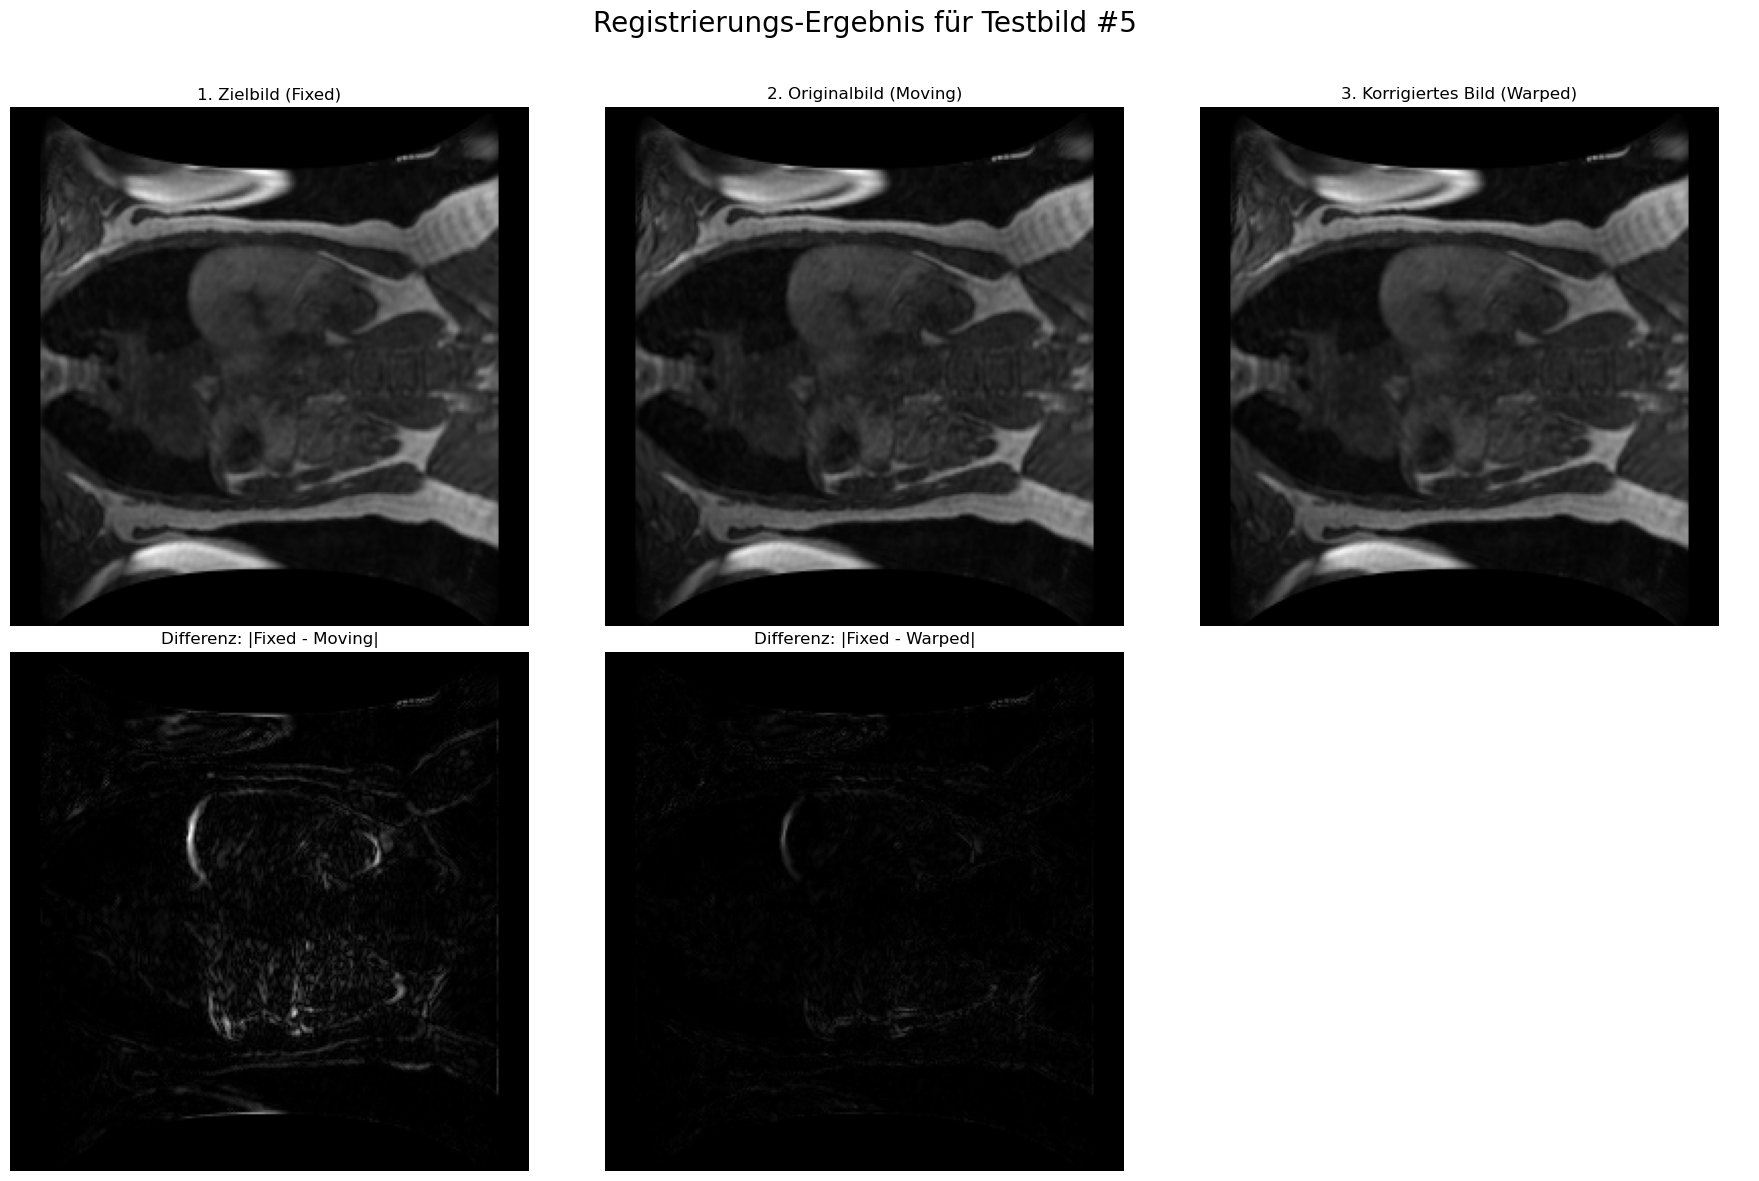


✔️ Test abgeschlossen.


In [30]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import zarr
import matplotlib.pyplot as plt

# =================================================================================
# 1. MODELL-DEFINITIONEN (müssen mit dem Training identisch sein)
# =================================================================================
# Kopiere die Klassen 'SpatialTransformer3D', 'UNet3D' und 'RegistrationModel'
# aus deinem Trainings-Skript hierher, damit Python weiß, wie das Modell aufgebaut ist.

class SpatialTransformer3D(nn.Module):
    def __init__(self, size):
        super().__init__()
        vectors = [torch.arange(0, s) for s in size]
        grids = torch.meshgrid(vectors, indexing='ij')
        grid = torch.stack(grids)
        grid = grid.unsqueeze(0)
        self.register_buffer('grid', grid.float(), persistent=False)
    def forward(self, src, flow):
        new_locs = self.grid + flow
        shape = flow.shape[2:]
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2 * (new_locs[:, i, ...] / (shape[i] - 1) - 0.5)
        new_locs = new_locs.permute(0, 2, 3, 4, 1)
        new_locs = new_locs[..., [2, 1, 0]]
        return F.grid_sample(src, new_locs, align_corners=True, padding_mode="border")

class UNet3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=3):
        super().__init__()
        self.enc1 = self._conv_block(in_channels, 16)
        self.enc2 = self._conv_block(16, 32)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = self._conv_block(32, 64)
        self.upconv2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(64, 32)
        self.upconv1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(32, 16)
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)
        self.final_conv.weight.data.zero_()
        self.final_conv.bias.data.zero_()
    def _conv_block(self, in_c, out_c):
        return nn.Sequential(nn.Conv3d(in_c, out_c, 3, 1, 1), nn.ReLU(True), nn.Conv3d(out_c, out_c, 3, 1, 1), nn.ReLU(True))
    def forward(self, x_fixed, x_moving):
        x = torch.cat([x_fixed, x_moving], dim=1)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.upconv2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final_conv(d1)

class RegistrationModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.registration_net = UNet3D()
        self.spatial_transformer = SpatialTransformer3D(size=input_size)
    def forward(self, moving, fixed):
        displacement_field = self.registration_net(fixed, moving)
        warped_moving = self.spatial_transformer(moving, displacement_field)
        return warped_moving, displacement_field

# =================================================================================
# 2. INFERENZ-SKRIPT
# =================================================================================

# --- Konfiguration ---
# Passe diese Pfade und Werte an
MODEL_PATH = "./registration_model.pth"
MOVING_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE"
FIXED_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
OUTPUT_VIS_PATH = "./registration_test_result.png"
TEST_INDEX = 5  # Welches Bildpaar aus dem Datensatz möchtest du testen?
SLICE_TO_SHOW = 26 # Welche Z-Schicht des 3D-Volumens soll angezeigt werden?

# --- Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Verwende Gerät: {device}")

# --- Lade das trainierte Modell ---
print(f"Lade trainiertes Modell von: {MODEL_PATH}")

# Bestimme die Input-Größe aus den Daten (inkl. Padding)
temp_zarr = zarr.open(FIXED_ZARR_PATH, mode='r')
original_shape = temp_zarr.shape
padded_shape = [s for s in original_shape[:3]]
for i in range(3):
    if padded_shape[i] % 4 != 0:
        padded_shape[i] = (padded_shape[i] // 4 + 1) * 4
input_size = (padded_shape[2], padded_shape[0], padded_shape[1]) # (D, H, W)

# Initialisiere und lade das Modell
model = RegistrationModel(input_size=input_size).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()  # WICHTIG: Modell in den Evaluationsmodus schalten!
print("Modell erfolgreich geladen.")


# --- Lade ein Test-Datenpaar ---
print(f"Lade Test-Datenpaar mit Index {TEST_INDEX}...")
moving_zarr = zarr.open(MOVING_ZARR_PATH, mode='r')
fixed_zarr = zarr.open(FIXED_ZARR_PATH, mode='r')

moving_np = moving_zarr[..., TEST_INDEX]
fixed_np = fixed_zarr[..., TEST_INDEX]

# Wende exakt die gleiche Vorverarbeitung wie im Training an!
def preprocess_volume(volume_np, padded_shape):
    tensor = torch.from_numpy(volume_np.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
    pad_d = padded_shape[2] - tensor.shape[1]
    pad_h = padded_shape[0] - tensor.shape[2]
    pad_w = padded_shape[1] - tensor.shape[3]
    padding = (pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2, pad_d // 2, pad_d - pad_d // 2)
    return F.pad(tensor, padding, "constant", 0)

moving_tensor = preprocess_volume(moving_np, padded_shape).to(device)
fixed_tensor = preprocess_volume(fixed_np, padded_shape).to(device)


# --- Führe Inferenz durch ---
print("Führe Inferenz durch...")
moving_tensor_batch = moving_tensor.unsqueeze(0)
fixed_tensor_batch = fixed_tensor.unsqueeze(0)

with torch.no_grad():  # WICHTIG: Deaktiviert die Gradientenberechnung für schnelleren Lauf
    # Übergib die neuen 5D-Tensoren an das Modell
    warped_tensor_batch, displacement_field = model(moving_tensor_batch, fixed_tensor_batch)

# --- Ergebnisse für die Visualisierung vorbereiten ---
# Konvertiere Tensoren zurück zu Numpy-Arrays auf der CPU
# KORREKTUR: Entferne die Batch- und Channel-Dimensionen für die Anzeige mit .squeeze()
fixed_display = fixed_tensor_batch.cpu().numpy().squeeze()
moving_display = moving_tensor_batch.cpu().numpy().squeeze()
warped_display = warped_tensor_batch.cpu().numpy().squeeze()

# Schneide das Padding für eine saubere Visualisierung ab
# (Hier einfachheitshalber weggelassen, aber für exakte Vergleiche wichtig)


# --- Visualisiere die Ergebnisse ---
print(f"Visualisiere Ergebnisse und speichere unter: {OUTPUT_VIS_PATH}")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Registrierungs-Ergebnis für Testbild #{TEST_INDEX}', fontsize=20)

# Zeige eine ausgewählte Schicht (Slice) aus den 3D-Volumen
s = SLICE_TO_SHOW 

# Reihe 1: Die Bilder
axes[0, 0].imshow(fixed_display[s, :, :], cmap='gray')
axes[0, 0].set_title('1. Zielbild (Fixed)')
axes[0, 0].axis('off')

axes[0, 1].imshow(moving_display[s, :, :], cmap='gray')
axes[0, 1].set_title('2. Originalbild (Moving)')
axes[0, 1].axis('off')

axes[0, 2].imshow(warped_display[s, :, :], cmap='gray')
axes[0, 2].set_title('3. Korrigiertes Bild (Warped)')
axes[0, 2].axis('off')

# Reihe 2: Die Differenzbilder
diff_before = np.abs(fixed_display[s, :, :] - moving_display[s, :, :])
axes[1, 0].imshow(diff_before, cmap='gray', vmin=0, vmax=diff_before.max())
axes[1, 0].set_title('Differenz: |Fixed - Moving|')
axes[1, 0].axis('off')

diff_after = np.abs(fixed_display[s, :, :] - warped_display[s, :, :])
axes[1, 1].imshow(diff_after, cmap='gray', vmin=0, vmax=diff_before.max()) # Gleiche Skala wie vorher!
axes[1, 1].set_title('Differenz: |Fixed - Warped|')
axes[1, 1].axis('off')

axes[1, 2].axis('off') # Leerer Plot für besseres Layout

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_VIS_PATH, dpi=150)
plt.show()

print("\n✔️ Test abgeschlossen.")

In [15]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import zarr
import tqdm  # Für eine schöne Fortschrittsanzeige

# =================================================================================
# 1. MODELL-DEFINITIONEN (müssen mit dem Training identisch sein)
# =================================================================================
# Kopiere die Klassen 'SpatialTransformer3D', 'UNet3D' und 'RegistrationModel'
# aus deinen vorherigen Skripten hierher.
class SpatialTransformer3D(nn.Module):
    def __init__(self, size):
        super().__init__()
        vectors = [torch.arange(0, s) for s in size]
        grids = torch.meshgrid(vectors, indexing='ij')
        grid = torch.stack(grids)
        grid = grid.unsqueeze(0)
        self.register_buffer('grid', grid.float(), persistent=False)
    def forward(self, src, flow):
        new_locs = self.grid + flow
        shape = flow.shape[2:]
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2 * (new_locs[:, i, ...] / (shape[i] - 1) - 0.5)
        new_locs = new_locs.permute(0, 2, 3, 4, 1)
        new_locs = new_locs[..., [2, 1, 0]]
        return F.grid_sample(src, new_locs, align_corners=True, padding_mode="border")

class UNet3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=3):
        super().__init__()
        self.enc1 = self._conv_block(in_channels, 16)
        self.enc2 = self._conv_block(16, 32)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = self._conv_block(32, 64)
        self.upconv2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(64, 32)
        self.upconv1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(32, 16)
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)
        self.final_conv.weight.data.zero_()
        self.final_conv.bias.data.zero_()
    def _conv_block(self, in_c, out_c):
        return nn.Sequential(nn.Conv3d(in_c, out_c, 3, 1, 1), nn.ReLU(True), nn.Conv3d(out_c, out_c, 3, 1, 1), nn.ReLU(True))
    def forward(self, x_fixed, x_moving):
        x = torch.cat([x_fixed, x_moving], dim=1)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.upconv2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final_conv(d1)

class RegistrationModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.registration_net = UNet3D()
        self.spatial_transformer = SpatialTransformer3D(size=input_size)
    def forward(self, moving, fixed):
        displacement_field = self.registration_net(fixed, moving)
        warped_moving = self.spatial_transformer(moving, displacement_field)
        return warped_moving, displacement_field

# =================================================================================
# 2. BATCH-VERARBEITUNGS-SKRIPT
# =================================================================================
if __name__ == '__main__':
    # --- Konfiguration ---
    # Passe diese Pfade an
    MODEL_PATH = "./registration_model_Bat1_50Ep_1e-4_NewLoss_SmoothWeight1e-3.pth"
    MOVING_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/DCE"
    FIXED_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
    OUTPUT_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/SpatialTransformer_2/warped_results_model_test2.zarr" # Speicherort für die Ergebnisse

    # --- Setup ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Verwende Gerät: {device}")

    # Sicherheitscheck, um versehentliches Überschreiben zu verhindern
    if os.path.exists(OUTPUT_ZARR_PATH):
        raise FileExistsError(f"Die Ausgabedatei {OUTPUT_ZARR_PATH} existiert bereits. Bitte löschen oder umbenennen.")

    # --- Modell laden ---
    print(f"Lade trainiertes Modell von: {MODEL_PATH}")
    moving_zarr_meta = zarr.open(MOVING_ZARR_PATH, mode='r')
    original_shape = moving_zarr_meta.shape
    padded_shape = [s for s in original_shape[:3]]
    for i in range(3):
        if padded_shape[i] % 4 != 0:
            padded_shape[i] = (padded_shape[i] // 4 + 1) * 4
    input_size = (padded_shape[2], padded_shape[0], padded_shape[1]) # (D, H, W)

    model = RegistrationModel(input_size=input_size).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Modell erfolgreich geladen.")

    # --- Daten-Setup ---
    moving_in_zarr = zarr.open(MOVING_ZARR_PATH, mode='r')
    fixed_in_zarr = zarr.open(FIXED_ZARR_PATH, mode='r')
    
    # Erstelle die leere Zarr-Datei für die Ausgabe
    print(f"Erstelle Ausgabedatei: {OUTPUT_ZARR_PATH}")
    output_zarr = zarr.open(OUTPUT_ZARR_PATH, mode='w', 
                            shape=moving_in_zarr.shape, 
                            chunks=moving_in_zarr.chunks, 
                            dtype=moving_in_zarr.dtype)

    # --- Lade und bereite das (die) fixe(n) Referenzbild(er) vor ---
    # Annahme: Alle moving_images werden gegen das erste fixed_image registriert.
    # Dies ist viel effizienter, als es in jeder Iteration neu zu laden.
    fixed_np = fixed_in_zarr[..., 50] # Nimm das erste fixe Bild als Referenz
    
    # Helper-Funktion für die Vorverarbeitung
    def preprocess_volume(volume_np, padded_shape):
        tensor = torch.from_numpy(volume_np.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
        pad_d = padded_shape[2] - tensor.shape[1]
        pad_h = padded_shape[0] - tensor.shape[2]
        pad_w = padded_shape[1] - tensor.shape[3]
        padding = (pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2, pad_d // 2, pad_d - pad_d // 2)
        return F.pad(tensor, padding, "constant", 0)

    fixed_tensor = preprocess_volume(fixed_np, padded_shape).to(device)
    fixed_tensor_batch = fixed_tensor.unsqueeze(0) # Füge Batch-Dimension hinzu

    # --- Hauptverarbeitungsschleife ---
    num_images = moving_in_zarr.shape[3]
    print(f"Starte Verarbeitung von {num_images} Volumen...")

    with torch.no_grad():
        for i in tqdm.trange(num_images, desc="Verarbeite Volumen"):
            # 1. Lese ein "moving" Volumen
            moving_np = moving_in_zarr[..., i]
            
            # 2. Wende die gleiche Vorverarbeitung an
            moving_tensor = preprocess_volume(moving_np, padded_shape).to(device)
            moving_tensor_batch = moving_tensor.unsqueeze(0)

            # 3. Führe die Inferenz durch
            warped_batch, _ = model(moving_tensor_batch, fixed_tensor_batch)

            # 4. Nachbearbeitung: Entferne Padding und konvertiere zurück
            warped_tensor = warped_batch.squeeze(0) # Entferne Batch-Dimension
            
            # Berechne, wie viel Padding entfernt werden muss
            pad_d_start = (padded_shape[2] - original_shape[2]) // 2
            pad_h_start = (padded_shape[0] - original_shape[0]) // 2
            pad_w_start = (padded_shape[1] - original_shape[1]) // 2
            
            # Schneide das Padding ab, um die Originalgröße zu erhalten
            cropped_warped = warped_tensor[
                :,
                pad_d_start : pad_d_start + original_shape[2],
                pad_h_start : pad_h_start + original_shape[0],
                pad_w_start : pad_w_start + original_shape[1]
            ]
            
            # Konvertiere zu Numpy und bringe in die Speicherform (H, W, D)
            warped_np = cropped_warped.squeeze(0).cpu().numpy().transpose(1, 2, 0)

            # 5. Speichere das Ergebnis in der Zarr-Datei
            output_zarr[..., i] = warped_np

    print(f"\n✔️ Verarbeitung abgeschlossen. Ergebnisse gespeichert in: {OUTPUT_ZARR_PATH}")

Verwende Gerät: cuda
Lade trainiertes Modell von: ./registration_model_Bat1_50Ep_1e-4_NewLoss_SmoothWeight1e-3.pth
Modell erfolgreich geladen.
Erstelle Ausgabedatei: /media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/SpatialTransformer_2/warped_results_model_test2.zarr
Starte Verarbeitung von 1000 Volumen...


Verarbeite Volumen: 100%|██████████| 1000/1000 [01:21<00:00, 12.32it/s]


✔️ Verarbeitung abgeschlossen. Ergebnisse gespeichert in: /media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/SpatialTransformer_2/warped_results_model_test2.zarr
